In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('netflix_movies1.csv')

In [5]:
df.head()

,release_date,title,overview,popularity,vote_count,vote_average,original_language,genre,poster_url
0,2018-01-10,Fun Unlimited 31,"A light-hearted story full of humor, chaos, an...",45.10,4915,5.9,en,Comedy,https://example.com/comedy_0.jpg
1,2025-09-20,Drama Queen 1,"A light-hearted story full of humor, chaos, an...",193.79,15503,6.7,en,Comedy,https://example.com/comedy_1.jpg
2,2025-10-10,Haunted Souls 45,A terrifying experience where dark forces haun...,188.71,17738,7.0,en,Horror,https://example.com/horror_2.jpg
3,2019-11-03,Shadow Strike 37,A fearless hero fights against powerful enemie...,85.78,8921,6.6,hi,Action,https://example.com/action_3.jpg
4,2018-08-08,Eternal ??? 25,A heartfelt love story filled with emotions an...,60.59,6240,7.4,es,Romance,https://example.com/romance_4.jpg


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   release_date       10000 non-null  str    
 1   title              10000 non-null  str    
 2   overview           10000 non-null  str    
 3   popularity         10000 non-null  float64
 4   vote_count         10000 non-null  int64  
 5   vote_average       10000 non-null  float64
 6   original_language  10000 non-null  str    
 7   genre              10000 non-null  str    
 8   poster_url         10000 non-null  str    
dtypes: float64(2), int64(1), str(6)
memory usage: 703.3 KB


In [7]:
df['genre'].head()

0     Comedy
1     Comedy
2     Horror
3     Action
4    Romance
Name: genre, dtype: str

In [11]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [12]:
df.describe()

,popularity,vote_count,vote_average
count,10000.000000,10000.000000,10000.000000
mean,108.870934,9238.303200,7.363400
std,52.665017,5099.050892,0.807895
min,12.540000,718.000000,5.500000
25%,62.967500,5104.000000,6.800000
50%,109.725000,8697.500000,7.400000
75%,154.042500,12765.500000,7.900000
max,204.640000,24082.000000,9.200000


In [15]:
df['release_date'] = pd.to_datetime(df['release_date'])
print(df['release_date'].dtypes)

datetime64[us]


In [16]:
df['release_date'] =df['release_date'].dt.year
df['release_date'].dtypes

dtype('int32')

In [17]:
df.head()

,release_date,title,overview,popularity,vote_count,vote_average,original_language,genre,poster_url
0,2018,Fun Unlimited 31,"A light-hearted story full of humor, chaos, an...",45.10,4915,5.9,en,Comedy,https://example.com/comedy_0.jpg
1,2025,Drama Queen 1,"A light-hearted story full of humor, chaos, an...",193.79,15503,6.7,en,Comedy,https://example.com/comedy_1.jpg
2,2025,Haunted Souls 45,A terrifying experience where dark forces haun...,188.71,17738,7.0,en,Horror,https://example.com/horror_2.jpg
3,2019,Shadow Strike 37,A fearless hero fights against powerful enemie...,85.78,8921,6.6,hi,Action,https://example.com/action_3.jpg
4,2018,Eternal ??? 25,A heartfelt love story filled with emotions an...,60.59,6240,7.4,es,Romance,https://example.com/romance_4.jpg


In [18]:
cols=['overview','original_language','poster_url']

In [19]:
df.drop(cols, axis = 1, inplace = True)
df.columns

Index(['release_date', 'title', 'popularity', 'vote_count', 'vote_average',
       'genre'],
      dtype='str')

In [20]:
df.head()

,release_date,title,popularity,vote_count,vote_average,genre
0,2018,Fun Unlimited 31,45.10,4915,5.9,Comedy
1,2025,Drama Queen 1,193.79,15503,6.7,Comedy
2,2025,Haunted Souls 45,188.71,17738,7.0,Horror
3,2019,Shadow Strike 37,85.78,8921,6.6,Action
4,2018,Eternal ??? 25,60.59,6240,7.4,Romance


categorizing **vote_average** column 
We would cut the **vote_average** values and make 4 categories: **popular** , **average** , **below_avg** , **not popular** to describe it more using **categorize_col()** function provided above.

In [29]:
def categorize_col(df, col, labels):

    edges = [df[col].describe()['min'], 
             df[col].describe()['25%'],
             df[col].describe()['50%'],
             df[col].describe()['75%'],
             df[col].describe()['max']]
    
    df[col] = pd.cut(df[col], edges , labels = labels, duplicates = 'drop')
    return df



In [30]:
labels = ['not_popular', 'below_avg', 'average', 'popular']
categorize_col(df, 'vote_average', labels)
df['vote_average'].unique()

['not_popular', 'below_avg', 'average', 'popular', NaN]
Categories (4, str): ['not_popular' < 'below_avg' < 'average' < 'popular']

In [31]:
df.head()


,release_date,title,popularity,vote_count,vote_average,genre
0,2018,Fun Unlimited 31,45.10,4915,not_popular,Comedy
1,2025,Drama Queen 1,193.79,15503,not_popular,Comedy
2,2025,Haunted Souls 45,188.71,17738,below_avg,Horror
3,2019,Shadow Strike 37,85.78,8921,not_popular,Action
4,2018,Eternal ??? 25,60.59,6240,below_avg,Romance


In [32]:
df['vote_average'].value_counts()

vote_average
not_popular    2692
below_avg      2672
popular        2441
average        2154
Name: count, dtype: int64

In [33]:
df.dropna(inplace = True)
df.isna().sum()

release_date    0
title           0
popularity      0
vote_count      0
vote_average    0
genre           0
dtype: int64

In [34]:
df.head()

,release_date,title,popularity,vote_count,vote_average,genre
0,2018,Fun Unlimited 31,45.10,4915,not_popular,Comedy
1,2025,Drama Queen 1,193.79,15503,not_popular,Comedy
2,2025,Haunted Souls 45,188.71,17738,below_avg,Horror
3,2019,Shadow Strike 37,85.78,8921,not_popular,Action
4,2018,Eternal ??? 25,60.59,6240,below_avg,Romance


In [35]:
df.info()

<class 'pandas.DataFrame'>
Index: 9959 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   release_date  9959 non-null   int32   
 1   title         9959 non-null   str     
 2   popularity    9959 non-null   float64 
 3   vote_count    9959 non-null   int64   
 4   vote_average  9959 non-null   category
 5   genre         9959 non-null   str     
dtypes: category(1), float64(1), int32(1), int64(1), str(2)
memory usage: 437.9 KB


In [36]:
df.nunique()

release_date      11
title           1595
popularity      7692
vote_count      7647
vote_average       4
genre              8
dtype: int64

In [37]:
df.head()

,release_date,title,popularity,vote_count,vote_average,genre
0,2018,Fun Unlimited 31,45.10,4915,not_popular,Comedy
1,2025,Drama Queen 1,193.79,15503,not_popular,Comedy
2,2025,Haunted Souls 45,188.71,17738,below_avg,Horror
3,2019,Shadow Strike 37,85.78,8921,not_popular,Action
4,2018,Eternal ??? 25,60.59,6240,below_avg,Romance


# Data Visualization


In [38]:
sns.set_style('whitegrid')

# what is the most frequent genre of movies released on Netflix?

In [41]:
df['genre'].describe()

count       9959
unique         8
top       Sci-Fi
freq        1319
Name: genre, dtype: object

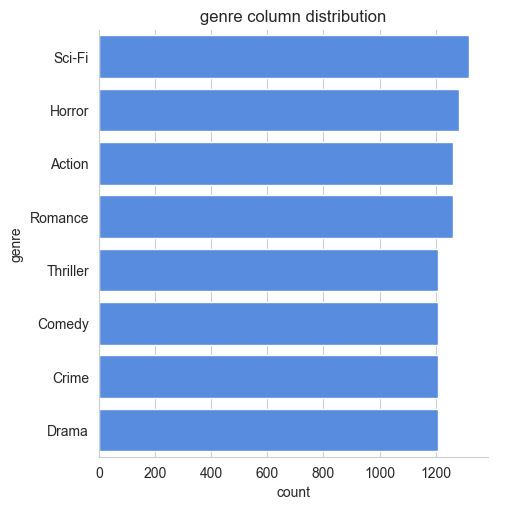

In [43]:
sns.catplot(y = 'genre',data =df, kind = 'count',
            order = df['genre'].value_counts().index,
            color = '#4287f5')
plt.title('genre column distribution')
plt.show()

# which has highest votes in vote avg column?

In [44]:
df.head()

,release_date,title,popularity,vote_count,vote_average,genre
0,2018,Fun Unlimited 31,45.10,4915,not_popular,Comedy
1,2025,Drama Queen 1,193.79,15503,not_popular,Comedy
2,2025,Haunted Souls 45,188.71,17738,below_avg,Horror
3,2019,Shadow Strike 37,85.78,8921,not_popular,Action
4,2018,Eternal ??? 25,60.59,6240,below_avg,Romance


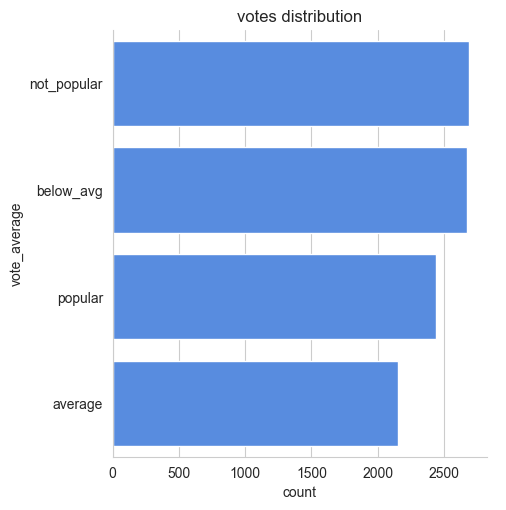

In [48]:
sns.catplot(y = 'vote_average', data = df, kind = 'count',
            order = df['vote_average'].value_counts().index,
            color = '#4287f5')
plt.title('votes distribution')
plt.show()

# what movie got the highest popularity? what's its genre?

In [49]:
df.head(2)

,release_date,title,popularity,vote_count,vote_average,genre
0,2018,Fun Unlimited 31,45.10,4915,not_popular,Comedy
1,2025,Drama Queen 1,193.79,15503,not_popular,Comedy


In [53]:
df[df['popularity'] == df['popularity'].max()]

,release_date,title,popularity,vote_count,vote_average,genre
2644,2026,Broken Lives 15,204.64,10436,popular,Drama


# what movie got the lowest popularity? what's its genre?

In [55]:
df[df['popularity'] == df['popularity'].min()]

,release_date,title,popularity,vote_count,vote_average,genre
8116,2016,Haunted Souls 16,12.54,1178,below_avg,Horror


# which year has the most filmed movies?

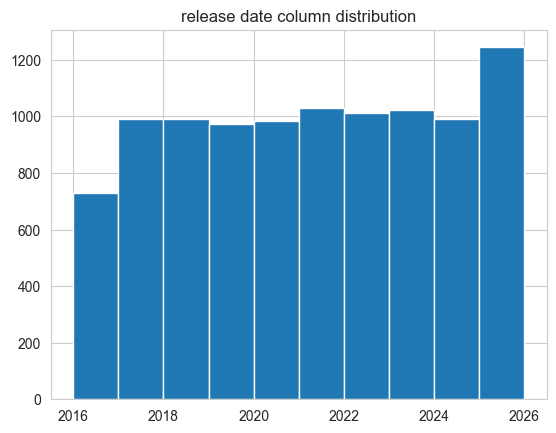

In [57]:
df['release_date'].hist()
plt.title('release date column distribution')
plt.show()